In [66]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [67]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'customer_tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             0 non-null      float64
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   customer_tenure   7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 
 17  

In [69]:
df.columns = df.columns.str.replace('.', '_')

In [70]:
df = df.rename(columns={
'customer_gender':'gender',
'customer_SeniorCitizen':'SeniorCitizen',
'customer_Partner':'Partner',
'customer_Dependents':'Dependents',
'phone_PhoneService':'PhoneService',
'phone_MultipleLines':'MultipleLines',
'internet_InternetService':'InternetService',
'internet_OnlineSecurity':'OnlineSecurity',
'internet_OnlineBackup':'OnlineBackup',
'internet_DeviceProtection':'DeviceProtection',
'internet_TechSupport':'TechSupport',
'internet_StreamingTV':'StreamingTV',
'internet_StreamingMovies':'StreamingMovies',
'account_Contract':'Contract',
'account_PaperlessBilling':'PaperlessBilling',
'account_PaymentMethod':'PaymentMethod',
'account_Charges_Monthly':'MonthlyCharges',
'account_Charges_Total':'TotalCharges'
})

In [71]:
df = df.rename(columns={'customer_tenure':'tenure'})

In [72]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [73]:
df.isnull().sum()

,0
customerID,0
Churn,7032
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [74]:
df = df.dropna()

In [75]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [76]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges


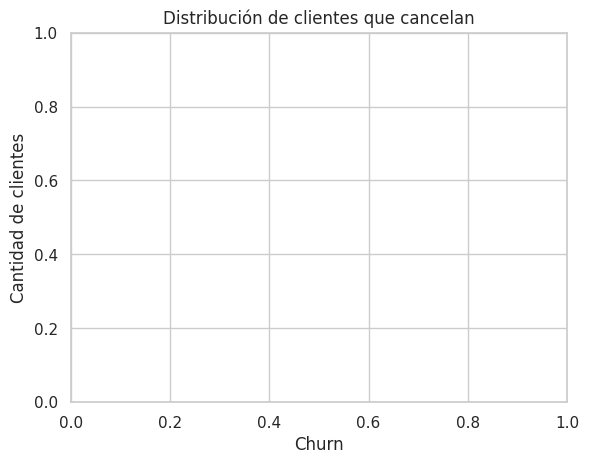

In [77]:
sns.countplot(x='Churn', data=df)

plt.title("Distribución de clientes que cancelan")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

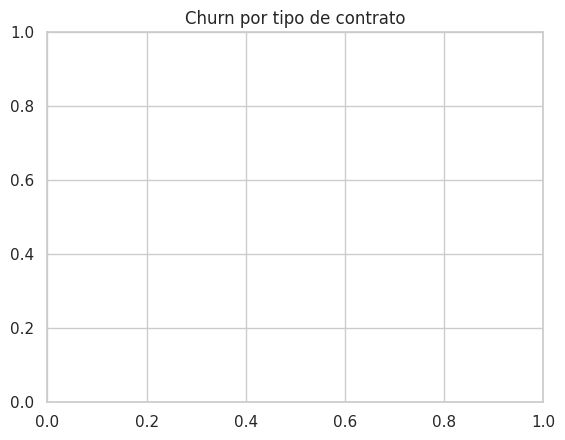

In [78]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn por tipo de contrato")

plt.show()

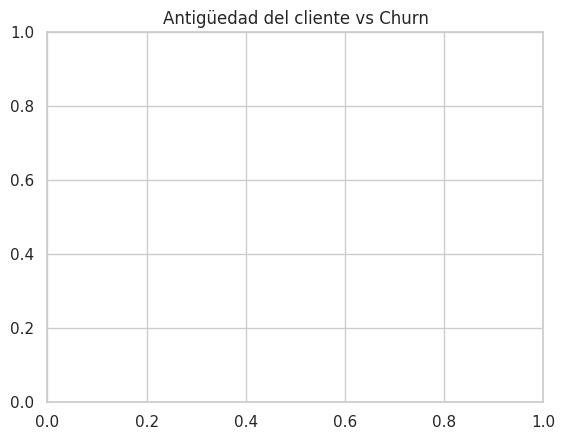

In [79]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Antigüedad del cliente vs Churn")

plt.show()

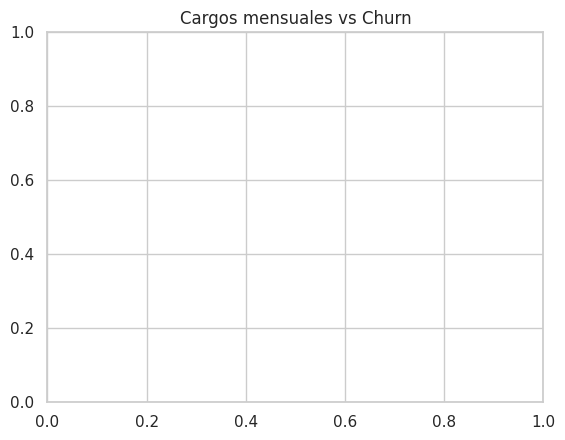

In [80]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Cargos mensuales vs Churn")

plt.show()

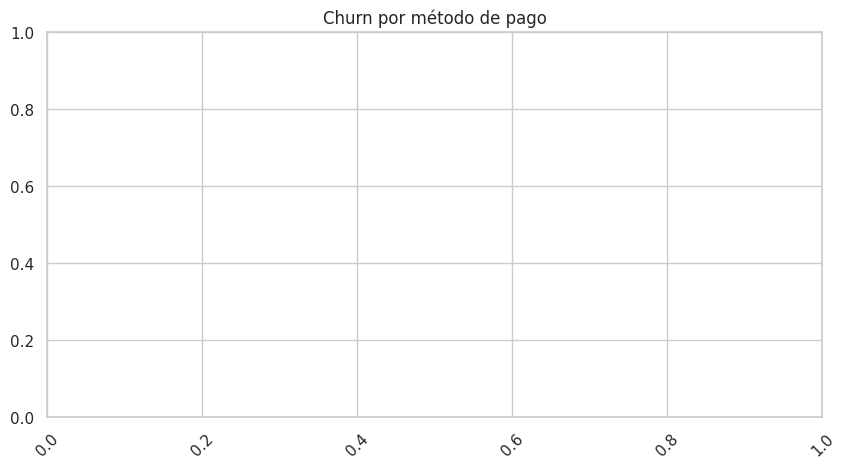

In [81]:
plt.figure(figsize=(10,5))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.xticks(rotation=45)

plt.title("Churn por método de pago")

plt.show()

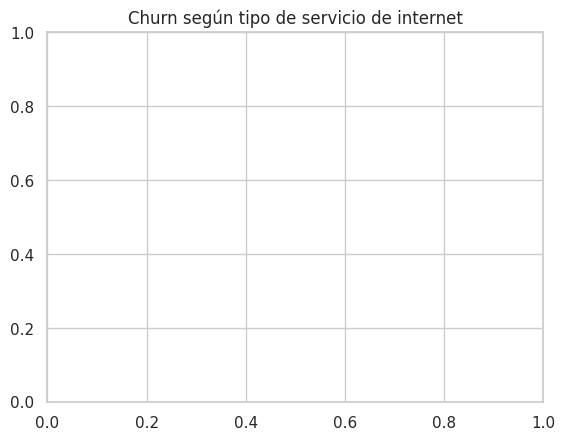

In [82]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Churn según tipo de servicio de internet")

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


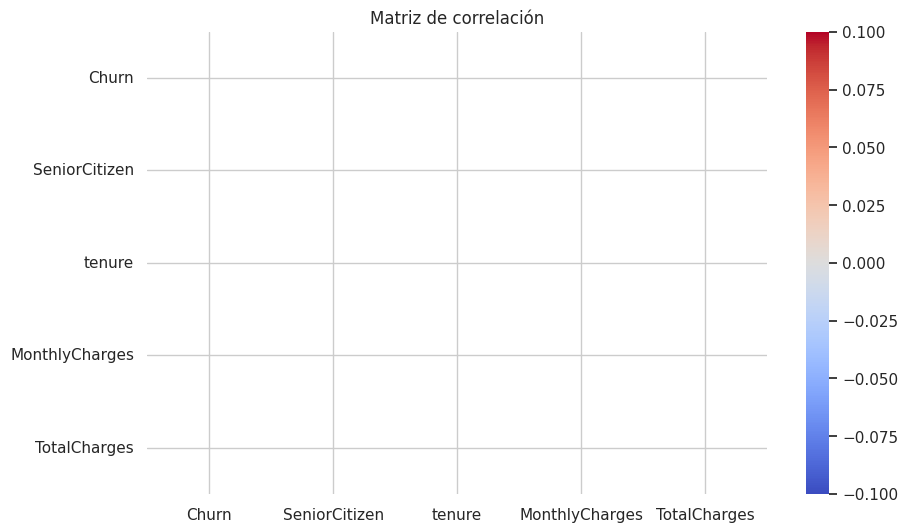

In [83]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Matriz de correlación")

plt.show()

In [84]:
df.to_csv("telecom_churn_limpio.csv", index=False)